In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv("train.csv")

In [3]:
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

In [5]:
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Week"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Order Day of Week"] = df["Order Date"].dt.day_name()
df["Order Quarter"] = df["Order Date"].dt.quarter

# Function to determine season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Order Season"] = df["Order Month"].apply(get_season)

In [6]:
df["Ship Year"] = df["Ship Date"].dt.year
df["Ship Month"] = df["Ship Date"].dt.month
df["Ship Week"] = df["Ship Date"].dt.isocalendar().week.astype(int)
df["Ship Day of Week"] = df["Ship Date"].dt.day_name()
df["Ship Quarter"] = df["Ship Date"].dt.quarter
df["Ship Season"] = df["Ship Month"].apply(get_season)

# Display sample
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ... Order Week  \
0      Claire Gute   Consumer  United States        Henderson  ...         45   
1      Claire Gute   Consumer  United States        Henderson  ...         45   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...         24   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...         41   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...         41   

   Order Day of Week Order Quarter Ord

In [7]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Country               0
City                  0
State                 0
Postal Code          11
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Order Year            0
Order Month           0
Order Week            0
Order Day of Week     0
Order Quarter         0
Order Season          0
Ship Year             0
Ship Month            0
Ship Week             0
Ship Day of Week      0
Ship Quarter          0
Ship Season           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Row ID                        int64
Order ID                     object
Order Date           datetime64[ns]
Ship Date            datetime64[ns]
Ship Mode                    object
Customer ID                  object
Customer Name                object
Segment                      object
Country                      object
City                         object
State                        object
Postal Code                 float64
Region                       object
Product ID                   object
Category                     object
Sub-Category                 object
Product Name                 object
Sales                       float64
Order Year                    int32
Order Month                   int32
Order Week                    int64
Order Day of Week            object
Order Quarter                 int32
Order Season                 object
Ship Year                     int32
Ship Month                    int32
Ship Week                     int64
Ship Day of Week            

In [10]:
daily_sales = (df.groupby("Order Date")["Sales"]
                .sum()
                .reset_index()
                .sort_values("Order Date"))

print("Daily Sales")
print(daily_sales.head())

Daily Sales
  Order Date     Sales
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158


In [11]:
weekly_sales = (daily_sales
    .set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .reset_index())

print("\nWeekly Sales")
print(weekly_sales.head())


Weekly Sales
  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914


In [12]:
monthly_sales = (daily_sales
    .set_index("Order Date")
    .resample("M")["Sales"]
    .sum()
    .reset_index())

print("\nMonthly Sales")
print(monthly_sales.head())


Monthly Sales
  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


C:\Users\vasu mittal\AppData\Local\Temp\ipykernel_7232\2788439826.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Sales"]


In [13]:
# Total revenue by category
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

highest_category = category_sales.idxmax()
highest_revenue = category_sales.max()

print(f"\nHighest Revenue Category: {highest_category}")
print(f"Total Revenue: ${highest_revenue:,.2f}")



Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Highest Revenue Category: Technology
Total Revenue: $827,455.87


In [14]:
# Extract year
df["Year"] = df["Order Date"].dt.year

# Annual sales by region
region_year_sales = (
    df.groupby(["Region", "Year"])["Sales"]
      .sum()
      .reset_index()
)

print(region_year_sales)

# Pivot for easier comparison
pivot = region_year_sales.pivot(
    index="Year",
    columns="Region",
    values="Sales"
)

print("\nAnnual Sales by Region")
print(pivot)

# Growth rate
growth = pivot.pct_change() * 100

print("\nYear-over-Year Growth (%)")
print(growth)

# Standard deviation of growth
consistency = growth.std().sort_values()

print("\nConsistency (Lower Std = More Consistent)")
print(consistency)


# Shipping duration
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

# Overall average
overall_avg = df["Shipping Days"].mean()

print(f"Overall Average Shipping Time: {overall_avg:.2f} days")

# Regional averages
region_shipping = (
    df.groupby("Region")["Shipping Days"]
      .agg(["mean", "min", "max", "std"])
      .round(2)
)

print(region_shipping)


     Region  Year        Sales
0   Central  2015  102920.5206
1   Central  2016  102425.1724
2   Central  2017  145673.8800
3   Central  2018  141627.3402
4      East  2015  127652.8190
5      East  2016  153225.1830
6      East  2017  178511.5380
7      East  2018  210129.1860
8     South  2015  103374.9055
9     South  2016   70076.0825
10    South  2017   93535.9035
11    South  2018  122164.5675
12     West  2015  145907.9630
13     West  2016  133709.5675
14     West  2017  182471.2285
15     West  2018  248130.9255

Annual Sales by Region
Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

Year-over-Year Growth (%)
Region    Central       East      South       West
Year                   

In [15]:
# Shipping duration
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

# Overall average
overall_avg = df["Shipping Days"].mean()

print(f"Overall Average Shipping Time: {overall_avg:.2f} days")

# Regional averages
region_shipping = (
    df.groupby("Region")["Shipping Days"]
      .agg(["mean", "min", "max", "std"])
      .round(2)
)

print(region_shipping)

Overall Average Shipping Time: 3.96 days
         mean  min  max   std
Region                       
Central  4.07    0    7  1.69
East     3.91    0    7  1.73
South    3.96    0    7  1.74
West     3.93    0    7  1.81


In [16]:
# Month and year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

# Monthly sales
monthly_sales = (
    df.groupby(["Year", "Month", "Month Name"])["Sales"]
      .sum()
      .reset_index()
)

# Pivot table
seasonality = monthly_sales.pivot(
    index="Month Name",
    columns="Year",
    values="Sales"
)

# Order months correctly
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

seasonality = seasonality.reindex(month_order)

print(seasonality)

# Average sales by month
avg_month = (
    monthly_sales.groupby("Month Name")["Sales"]
    .mean()
    .reindex(month_order)
    .sort_values(ascending=False)
)

avg_month.sort_values(ascending=False)

Year              2015        2016        2017         2018
Month Name                                                 
January     14205.7070  18066.9576  18542.4910   43476.4740
February     4519.8920  11951.4110  22978.8150   19920.9974
March       55205.7970  32339.3184  51165.0590   58863.4128
April       27906.8550  34154.4685  38679.7670   35541.9101
May         23644.3030  29959.5305  56656.9080   43825.9822
June        34322.9356  23599.3740  39724.4860   48190.7277
July        33781.5430  28608.2590  38320.7830   44825.1040
August      27117.5365  36818.3422  30542.2003   62837.8480
September   81623.5268  63133.6060  69193.3909   86152.8880
October     31453.3930  31011.7375  59583.0330   77448.1312
November    77907.6607  75249.3995  79066.4958  117938.1550
December    68167.0585  74543.6012  95739.1210   83030.3888


Month Name
November     87540.427750
December     80370.042375
September    75025.852925
October      49874.073675
March        49393.396800
August       39328.981750
May          38521.680925
June         36459.380825
July         36383.922250
April        34070.750150
January      23572.907400
February     14842.778850
Name: Sales, dtype: float64

Technology contributes the largest share of sales with $827,455.87.

The East region demonstrates the most stable and continuous year-over-year growth, making it the most consistent performing region.

The average shipping time across all orders is 3.96 days.
Regional observations:
Central has the longest average shipping time (4.07 days).
East has the shortest (3.91 days).
The difference between regions is only about 0.16 days, indicating shipping performance is fairly consistent nationwide.

Yes, the data exhibits clear seasonality. November and December consistently record the highest average sales across all years, indicating a strong increase in demand during the year-end holiday shopping season.On the other hand, January and February have the lowest average sales, indicating a post-holiday decline in customer purchases.

Time Series Analysis & Decomposition

C:\Users\vasu mittal\AppData\Local\Temp\ipykernel_7232\4235593356.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = (df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]


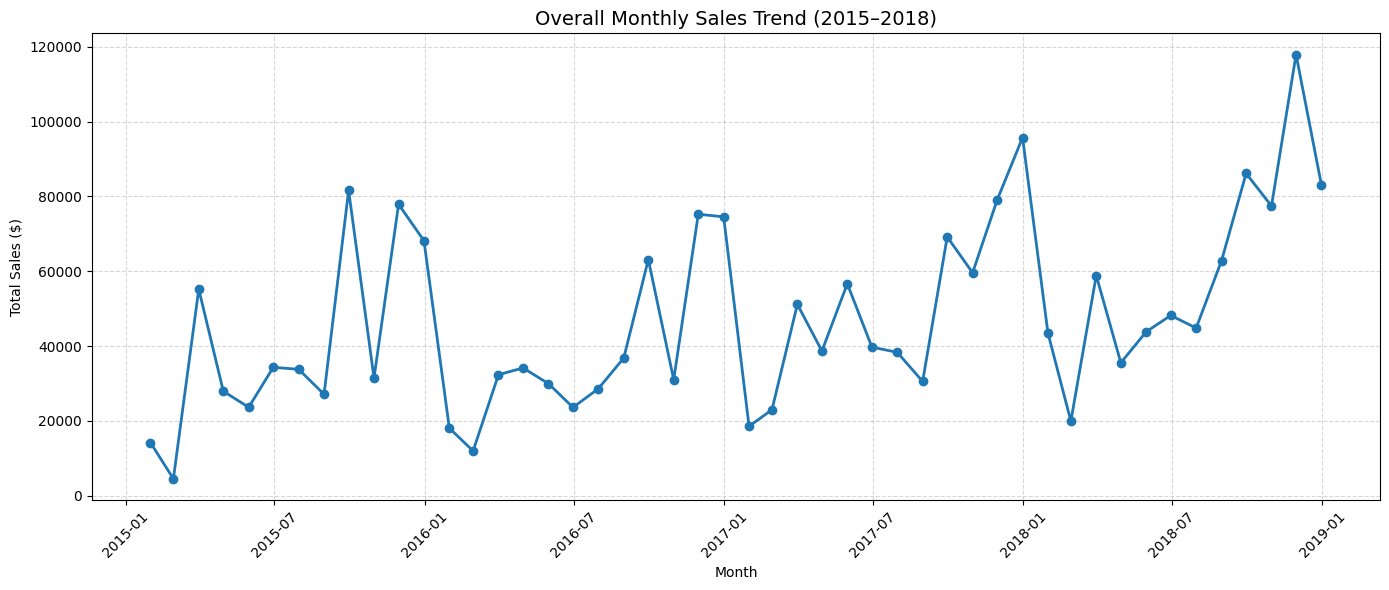

In [17]:
monthly_trend = (df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
                .sum()
                .reset_index())

plt.figure(figsize=(14,6))
plt.plot(monthly_trend["Order Date"], monthly_trend["Sales"],
         marker="o", linewidth=2)

plt.title("Overall Monthly Sales Trend (2015–2018)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
import subprocess
subprocess.check_call(['pip', 'install', 'statsmodels'])
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_sales_ts = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
      .sum()
)

print(monthly_sales_ts.head())

decomposition = seasonal_decompose(monthly_sales_ts, model="additive", period=12)

Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64


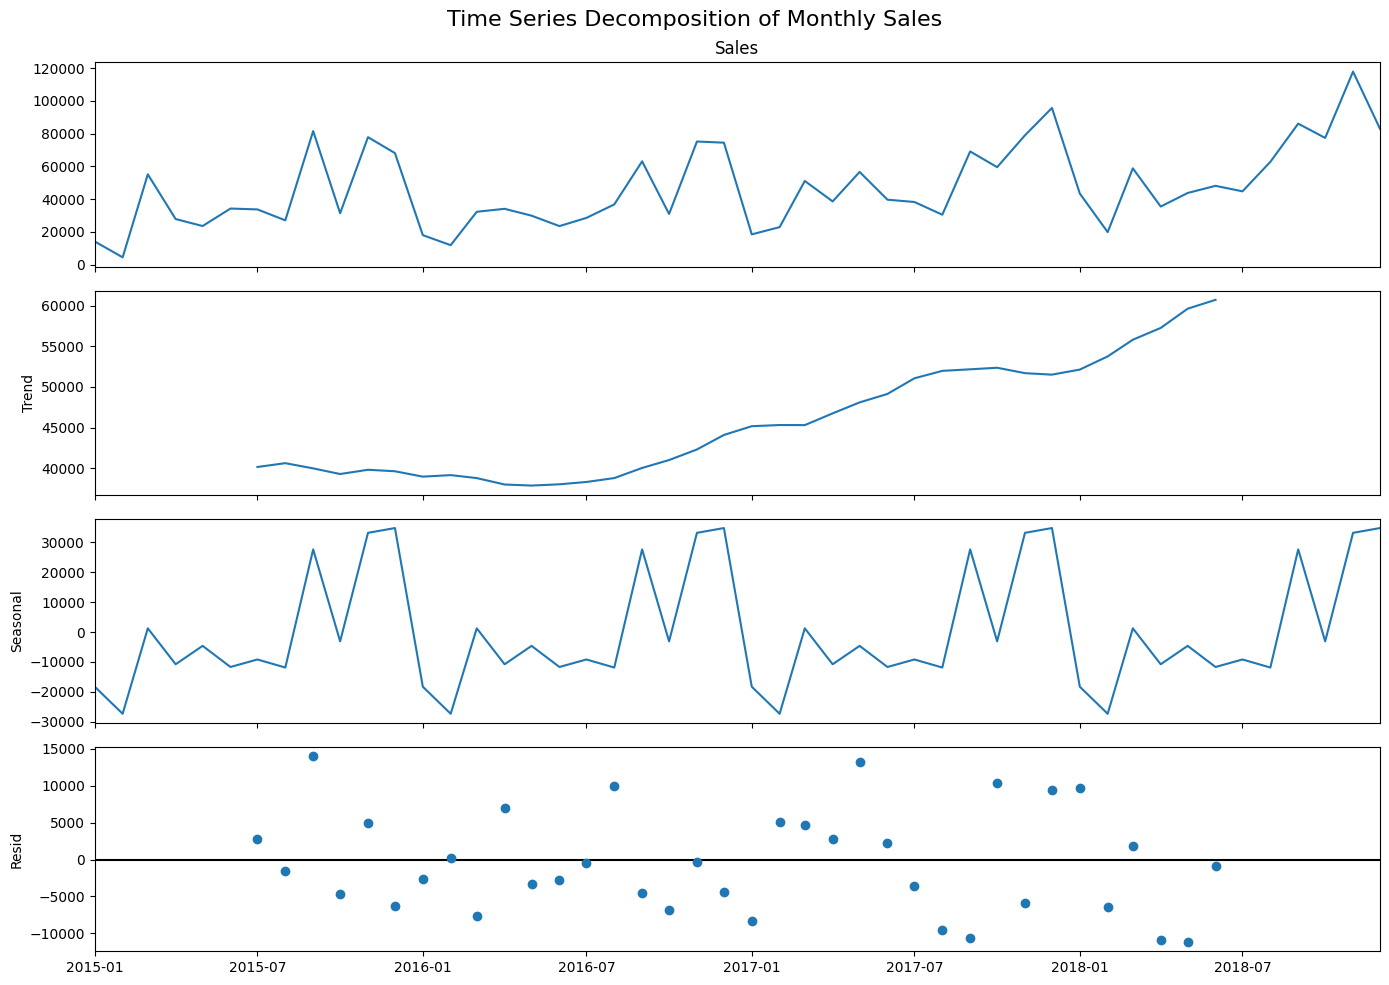

In [19]:
fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.suptitle("Time Series Decomposition of Monthly Sales", fontsize=16)
plt.tight_layout()
plt.show()

The trend shows an overall upward movement in monthly sales from 2015 to 2018.

The seasonal component exhibits a strong and consistent yearly pattern, with similar peaks and troughs repeating every 12 months.
Analysis showing higher sales in September, November, and December and lower sales in January and February.

Months with Highest Residual Noise-

The largest positive residuals occur approximately around August–September 2015, May 2017, and October–December 2017, where actual sales exceeded the model's expected values.
The largest negative residuals appear around August–September 2017 and March–May 2018, indicating months where sales were noticeably lower than expected after accounting for trend and seasonality.

In [20]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF Test
def adf_test(series, title='Time Series'):
    result = adfuller(series.dropna())

    print(f'ADF Test: {title}')
    print('-' * 40)
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print(f'Used Lags     : {result[2]}')
    print(f'Observations  : {result[3]}')

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')

    if result[1] < 0.05:
        print("\nConclusion: The series is STATIONARY.")
    else:
        print("\nConclusion: The series is NON-STATIONARY.")

# Test original monthly sales
adf_test(monthly_sales_ts, "Original Monthly Sales")

ADF Test: Original Monthly Sales
----------------------------------------
ADF Statistic : -4.4161
p-value       : 0.0003
Used Lags     : 0
Observations  : 47

Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008

Conclusion: The series is STATIONARY.


In [21]:
# First-order differencing
monthly_sales_diff = monthly_sales_ts.diff().dropna()

# Display first few values
print(monthly_sales_diff.head())

adf_test(monthly_sales_diff, "First Differenced Monthly Sales")

Order Date
2015-02-01    -9685.8150
2015-03-01    50685.9050
2015-04-01   -27298.9420
2015-05-01    -4262.5520
2015-06-01    10678.6326
Freq: MS, Name: Sales, dtype: float64
ADF Test: First Differenced Monthly Sales
----------------------------------------
ADF Statistic : -8.7271
p-value       : 0.0000
Used Lags     : 10
Observations  : 36

Critical Values:
   1%: -3.6267
   5%: -2.9460
   10%: -2.6117

Conclusion: The series is STATIONARY.


stationary time series is one whose statistical properties such as mean and variance remain stable over time.

The Augmented Dickey-Fuller (ADF) Test checks whether a time series is stationary.

Null Hypothesis (H₀): The series is non-stationary.
Alternative Hypothesis (H₁): The series is stationary.

Decision rule:

If p-value < 0.05, reject the null hypothesis → the series is stationary.

If p-value ≥ 0.05, fail to reject the null hypothesis → the series is non-stationary.

The p-value (0.0003) is less than 0.05.

Therefore, we reject the null hypothesis that the series is non-stationary.

The ADF statistic (-4.4161) is also more negative than all the critical values, providing additional evidence that the series is stationary.

Since the original monthly sales series is already stationary (ADF p-value = 0.0003 < 0.05), first-order differencing is not required.

In [ ]:
# Model1-SARIMA model

from statsmodels.tsa.statespace.sarimax import SARIMAX

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
      .sum()
)

monthly_sales.index.freq = "MS"

model = SARIMAX(
    monthly_sales,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = model.fit()

print(sarima_model.summary())


#The monthly sales data showed strong annual seasonality (12-month cycle) from the seasonal decomposition.
#The Augmented Dickey-Fuller (ADF) test indicated that the original series was already stationary (p = 0.0003), so d = 0 was selected.
#Seasonal differencing (D = 1) was included to account for recurring yearly patterns.
#SARIMA (1,0,1)(1,1,1,12) was chosen because it is a simple model that can capture both the short-term changes in sales and the yearly seasonal pattern.
#The values p = 1, q = 1, P = 1, and Q = 1 provide a simple baseline that captures recent sales patterns and yearly seasonality.

C:\Users\vasu mittal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -239.060
Date:                            Sun, 12 Jul 2026   AIC                            488.120
Time:                                    22:07:02   BIC                            493.575
Sample:                                01-01-2015   HQIC                           489.405
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9927      0.018     56.542      0.000       0.958       1.027
ma.L1         -1.0150      0.159   

In [24]:
forecast = sarima_model.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

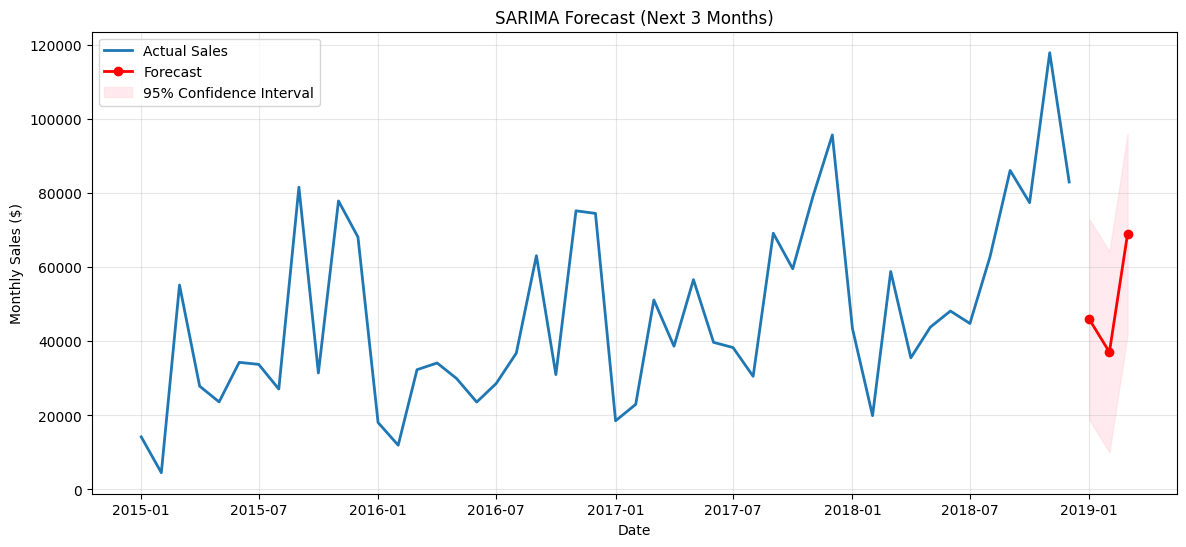

In [25]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales,
         label="Actual Sales",
         linewidth=2)

plt.plot(forecast_mean,
         color="red",
         marker="o",
         linewidth=2,
         label="Forecast")

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Monthly Sales ($)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [26]:
forecast_df = pd.DataFrame({
    "Forecast": forecast_mean,
    "Lower CI": forecast_ci.iloc[:,0],
    "Upper CI": forecast_ci.iloc[:,1]
})

print(forecast_df)

                Forecast      Lower CI      Upper CI
2019-01-01  45942.740969  18855.871856  73029.610081
2019-02-01  37103.176826  10016.917001  64189.436651
2019-03-01  69034.926533  41950.295849  96119.557216


In [27]:
# Model2-Facebook Prophet model
!pip install prophet
from prophet import Prophet

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.1 MB 5.9 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/12.1 MB 4.7 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.1 MB 4.3 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/12.1 MB 4.2 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.1 MB 4.1 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.1 MB 4.0 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/12.1 MB 3.6 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.1 MB 3.4 MB/s eta 0:00:02
   --------------------- ------------------ 6.6/12.1 MB 3.3 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.1 MB 3.3 MB/s eta 0:00:02
   -------------------------- ------------- 8.1/12.1 MB 3.4 MB/s eta 0:00:02
   --

C:\Users\vasu mittal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [28]:
# Monthly sales
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
      .sum()
      .reset_index()
)

# Rename columns for Prophet
prophet_df = monthly_sales.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [29]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_df)

23:18:46 - cmdstanpy - INFO - Chain [1] start processing
23:18:47 - cmdstanpy - INFO - Chain [1] done processing


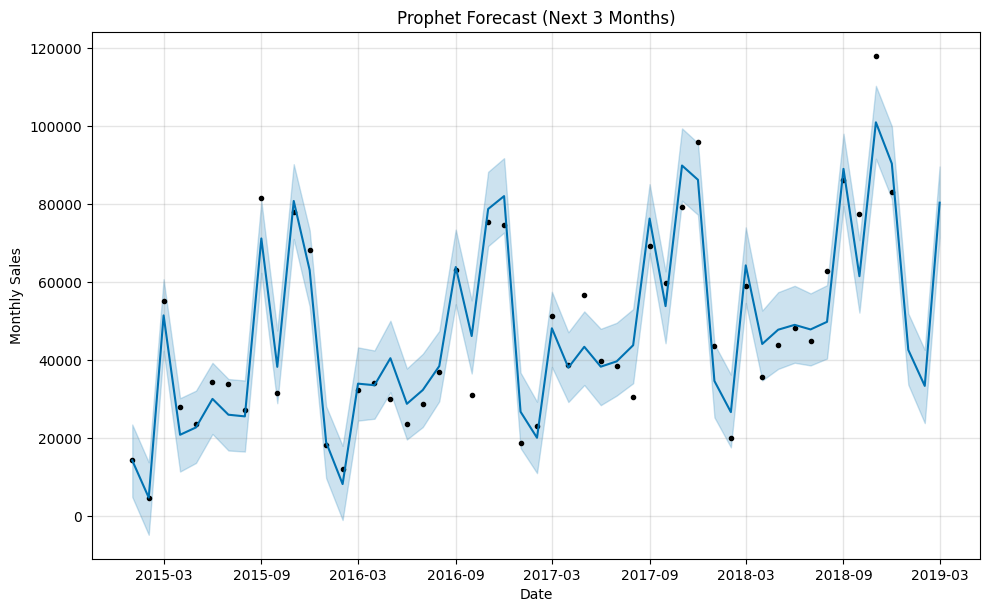

In [30]:
future = model.make_future_dataframe(
    periods=3,
    freq="MS"
)
forecast = model.predict(future)

fig = model.plot(forecast)

plt.title("Prophet Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")

plt.show()

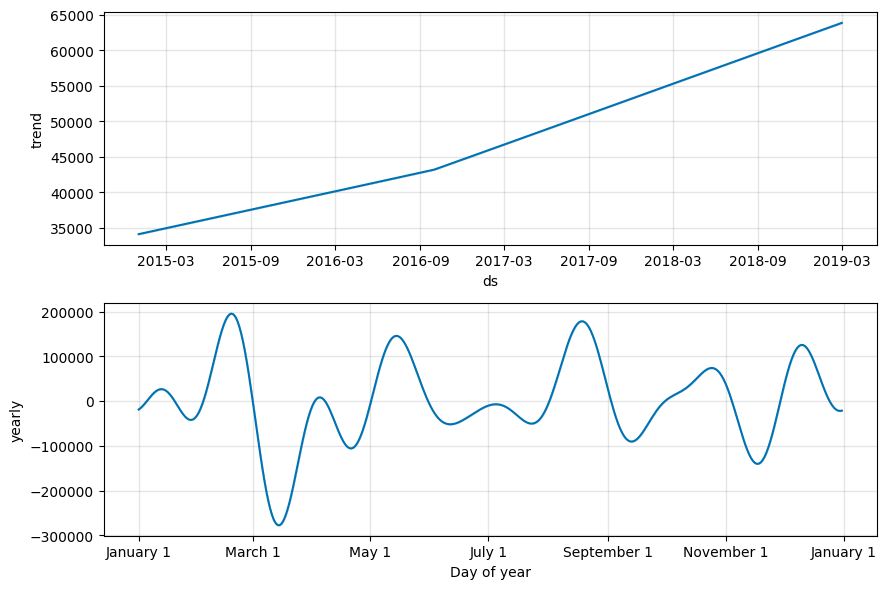

In [31]:
model.plot_components(forecast)
plt.show()

In [32]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(3)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-01,42548.142575,33637.451071,51879.970259
49,2019-02-01,33310.125086,23768.099077,42549.372477
50,2019-03-01,80304.673389,71407.414847,89590.045758


Yearly Seasonality

The yearly seasonality component confirms recurring annual patterns in sales.Sales are generally higher toward the end of the year
(especially around November and December) and lower during the beginning of the year (January and February).
This matches the seasonality observed during exploratory data analysis.

In [ ]:
#Model3-XGBoost model

!pip install xgboost
from xgboost import XGBRegressor
